<a href="https://colab.research.google.com/github/sumitgoski/neo_spitzer_spectra/blob/main/cutouts_working_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Installation
!pip install git+https://github.com/B612-Asteroid-Institute/cutouts.git@main#egg=cutouts

  Cloning https://github.com/B612-Asteroid-Institute/cutouts.git (to revision main) to /tmp/pip-install-jk5ed2e8/cutouts_e4d4ac21edf54bdab8403048d6487fdc
  Running command git clone --filter=blob:none --quiet https://github.com/B612-Asteroid-Institute/cutouts.git /tmp/pip-install-jk5ed2e8/cutouts_e4d4ac21edf54bdab8403048d6487fdc
  Resolved https://github.com/B612-Asteroid-Institute/cutouts.git to commit 9cf6b1d6f910dcf0de0d6df44e8335599d5b756a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 13.8 MB/s eta 0:00:00
  Created wheel for cutouts: filename=cutouts-0.2.dev107+g9cf6b1d-py3-none-any.whl size=279904 sha256=74bc224f5ed5c381ad31cf1d1df9b7373653855a0b564c3152cbf07abb0cdd01
  Stored in directory: /tmp/pip-ephem-wheel-cache-zgprpfpm/wheels/68/b6/09/a1abdcc32e7b63d8df822a5d9df32fdf6b19bd5cdedd3767c4
Successfully built cutouts


In [ ]:
# Cell 2: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from cutouts import get_cutouts
from cutouts import plot_cutouts
import pathlib

In [ ]:
# Cell 3: Create a sample data file
# You can either upload your own CSV or create a sample one
sample_data = {
    'pred_ra_deg': [15.0, 15.1, 15.2],
    'pred_dec_deg': [-25.0, -25.1, -25.2],
    'pred_vra_degpday': [0.5, 0.5, 0.5],
    'pred_vdec_degpday': [0.3, 0.3, 0.3],
    'obscode': ['G96', 'G96', 'G96'],
    'mag': [20.0, 20.1, 20.2],
    'filter': ['r', 'r', 'r'],
    'mag_sigma': [0.1, 0.1, 0.1],
    'mjd_utc': [59000.0, 59001.0, 59002.0],
    'exposure_id': ['exp1', 'exp2', 'exp3']
}

observations = pd.DataFrame(sample_data)
observations.to_csv('sample_observations.csv', index=False)

In [ ]:
# Cell 4: Extract relevant quantities
ra = observations["pred_ra_deg"].values
dec = observations["pred_dec_deg"].values
vra = observations["pred_vra_degpday"].values
vdec = observations["pred_vdec_degpday"].values
obscode = observations["obscode"].values
mag = observations["mag"].values
filter = observations["filter"].values
mag_sigma = observations["mag_sigma"].values
times = Time(observations["mjd_utc"].values, scale="utc", format="mjd")
exposure_id = observations["exposure_id"].values

In [ ]:
# Cell 5: Create cutout requests dataframe
cutout_requests = pd.DataFrame({
    'observatory_code': obscode,
    'exposure_start_mjd': times.mjd,
    'ra_deg': ra,
    'dec_deg': dec,
    'exposure_id': exposure_id,
    'height_arcsec': 20.0,  # default value, adjust as needed
    'width_arcsec': 20.0,   # default value, adjust as needed
    'delta_time': 1e-8      # default tolerance
})

# Get the cutouts
cutout_paths, cutout_results = get_cutouts(
    cutout_requests,
    out_dir=pathlib.Path("cutouts")
)

In [ ]:
import pandas as pd
from cutouts import get_cutouts
import pathlib

# Try different MJD values or narrow the time window
cutout_requests = pd.DataFrame({
    'observatory_code': ['I41'],
    'exposure_start_mjd': [58205.3036],  # Use the actual MJD found
    'ra_deg': [180.0],
    'dec_deg': [30.0],
    'height_arcsec': [20.0],
    'width_arcsec': [20.0],
    'delta_time': [0.001]  # Smaller window for more precise matching
})

cutout_paths, results = get_cutouts(
    cutout_requests,
    out_dir=pathlib.Path("cutouts"),
    timeout=180,
    use_cache=True
)

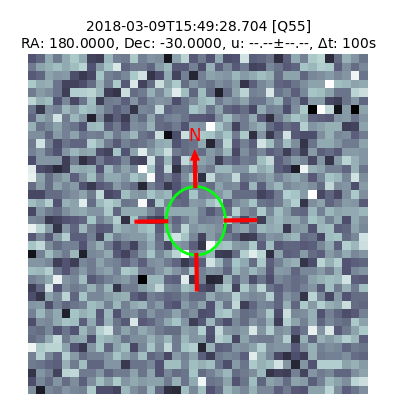

In [ ]:
import pandas as pd
import pathlib
from cutouts import get_cutouts
from cutouts import plot_cutouts
import numpy as np

# Create a DataFrame with the cutout requests
cutout_requests = pd.DataFrame({
    'observatory_code': ['Q55'],  # Q55 is SkyMapper's observatory code
    'exposure_start_mjd': [58200.0],  # Example MJD
    'ra_deg': [180.0],  # Example RA (in degrees)
    'dec_deg': [-30.0],  # Example Dec (in degrees)
    'height_arcsec': [20.0],  # Cutout height
    'width_arcsec': [20.0],  # Cutout width
    'delta_time': [20.0]  # Time window in days
})

# Get the cutouts
results, comparison_results = get_cutouts(
    cutout_requests,
    out_dir=pathlib.Path("skymapper_cutouts"),
    timeout=180,
    use_cache=True
)

# Create visualization if we got any results
if len(results) > 0 and 'error' not in results[0]:
    # Access the first result dictionary
    result = results[0]

    plot_data = pd.DataFrame({
        'path': [result['cutout_image_path']],
        'exposure_start': [result['exposure_start_mjd']],
        'ra': [result['ra_deg']],
        'dec': [result['dec_deg']],
        'vra': [0.0],  # No motion
        'vdec': [0.0],  # No motion
        'obj_ra': [result['ra_deg']],
        'obj_dec': [result['dec_deg']],
        'filter': [result['filter']],
        'mag': [np.nan],  # Use np.nan instead of None
        'mag_sigma': [np.nan],  # Use np.nan instead of None
        'exposure_duration': [result['exposure_duration']],
        'obscode': ['Q55']
    })

    # Create the plot
    fig, ax = plot_cutouts(
        plot_data,
        cutout_height_arcsec=20,
        cutout_width_arcsec=20,
        velocity_vector=False  # No motion vectors
    )

    # Save the plot
    fig.savefig('skymapper_cutouts.png', bbox_inches='tight', dpi=200)
else:
    print("No cutouts found or error occurred")
    if len(results) > 0:
        print(f"Error: {results[0].get('error', 'Unknown error')}")

In [ ]:
from cutouts import get_cutouts
from cutouts.io.types import CutoutRequest
import pandas as pd
import pathlib

def get_single_cutout(ra_deg: float, dec_deg: float, time_mjd: float,
                     delta_time: float = 20.0,
                     observatory_code: str = "Q55") -> dict:
    """
    Get a single cutout image for given coordinates and time.

    Parameters
    ----------
    ra_deg : float
        Right Ascension in degrees
    dec_deg : float
        Declination in degrees
    time_mjd : float
        Time in Modified Julian Date
    delta_time : float
        Time window in days to search for images
    observatory_code : str
        Observatory code (Q55=SkyMapper, 695=DECam)

    Returns
    -------
    dict
        Dictionary containing cutout metadata and paths
    """

    # Ensure all numeric inputs are floats
    time_mjd = float(time_mjd)
    ra_deg = float(ra_deg)
    dec_deg = float(dec_deg)
    delta_time = float(delta_time)

    # Create request DataFrame
    cutout_request = pd.DataFrame({
        'observatory_code': [observatory_code],
        'exposure_start_mjd': [time_mjd],
        'ra_deg': [ra_deg],
        'dec_deg': [dec_deg],
        'height_arcsec': [20.0],  # Default size
        'width_arcsec': [20.0],   # Default size
        'delta_time': [delta_time]
    })

    # Get cutouts
    results, _ = get_cutouts(
        cutout_request,
        out_dir=pathlib.Path("cutouts"),
        timeout=180,
        use_cache=True
    )

    # Return first result if available
    if results and len(results) > 0:
        if 'error' not in results[0]:
            return results[0]
        else:
            raise ValueError(f"Error retrieving cutout: {results[0]['error']}")
    else:
        raise ValueError("No cutouts found")

In [ ]:
try:
    result = get_single_cutout(
        ra_deg=180.0,
        dec_deg=-30.0,
        time_mjd=58200.0,
        delta_time=20.0,
        observatory_code="Q55"
    )

    print(f"Found cutout at MJD: {result['exposure_start_mjd']}")
    print(f"Image path: {result['cutout_image_path']}")

except ValueError as e:
    print(f"Error: {e}")

Found cutout at MJD: 58186.65936
Image path: cutouts/cutout_2018-03-09T15:49:28.704_ra180.00000000_dec-30.00000000_expid_20180309154928_h20.0_w20.0.fits


In [ ]:
def get_single_cutout(ra_deg: float, dec_deg: float, time_mjd: float,
                     delta_time: float = 20.0,
                     observatory_code: str = "Q55",
                     out_dir: str = "cutouts",
                     save_png: bool = True) -> dict:
    """
    Get a single cutout image and save as PNG.
    """
    # Create request DataFrame
    cutout_request = pd.DataFrame({
        'observatory_code': [observatory_code],
        'exposure_start_mjd': [float(time_mjd)],
        'ra_deg': [float(ra_deg)],
        'dec_deg': [float(dec_deg)],
        'height_arcsec': [20.0],
        'width_arcsec': [20.0],
        'delta_time': [float(delta_time)]
    })

    # Get cutouts
    results, _ = get_cutouts(
        cutout_request,
        out_dir=pathlib.Path(out_dir),
        timeout=180,
        use_cache=True
    )

    if save_png and results and len(results) > 0:
        # Create candidates DataFrame for plotting
        plot_data = pd.DataFrame({
            'path': [results[0]['cutout_image_path']],
            'exposure_start': [results[0]['exposure_start_mjd']],
            'ra': [ra_deg],
            'dec': [dec_deg],
            'vra': [0.0],  # Set to 0 if no velocity info
            'vdec': [0.0], # Set to 0 if no velocity info
            'obj_ra': [ra_deg],
            'obj_dec': [dec_deg],
            'mag': [np.nan],
            'mag_sigma': [np.nan],
            'filter': [results[0]['filter']],
            'obscode': [observatory_code],
            'exposure_duration': [results[0]['exposure_duration']]
        })

        # Plot and save as PNG
        fig, ax = plot_cutouts(plot_data)
        png_path = str(results[0]['cutout_image_path']).replace('.fits', '.png')
        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # Add PNG path to results
        results[0]['png_path'] = png_path

    return results[0] if results and len(results) > 0 else None

/usr/local/lib/python3.10/dist-packages/cutouts/plot.py:223: RuntimeWarning: invalid value encountered in scalar divide
  vra_hat = vra / np.sqrt(vra**2 + vdec**2)
/usr/local/lib/python3.10/dist-packages/cutouts/plot.py:224: RuntimeWarning: invalid value encountered in scalar divide
  vdec_hat = vdec / np.sqrt(vra**2 + vdec**2)


AttributeError: 'list' object has no attribute 'T'

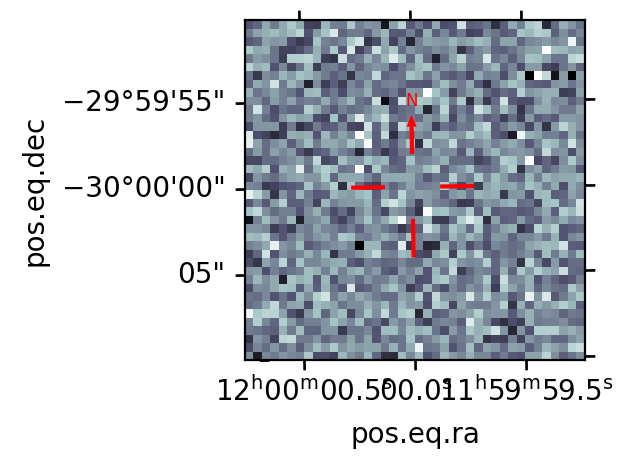

In [ ]:
result = get_single_cutout(
    ra_deg=180.0,
    dec_deg=-30.0,
    time_mjd=58200.0,
    observatory_code="Q55"
)

if result:
    print(f"FITS file: {result['cutout_image_path']}")
    print(f"PNG file: {result['png_path']}")

In [ ]:
def get_single_cutout(ra_deg: float, dec_deg: float, time_mjd: float,
                     delta_time: float = 20.0,
                     observatory_code: str = "Q55",
                     out_dir: str = "cutouts",
                     save_png: bool = True) -> dict:
    """
    Get a single cutout image and save as PNG.
    """
    # Create request DataFrame
    cutout_request = pd.DataFrame({
        'observatory_code': [observatory_code],
        'exposure_start_mjd': [float(time_mjd)],
        'ra_deg': [float(ra_deg)],
        'dec_deg': [float(dec_deg)],
        'height_arcsec': [20.0],
        'width_arcsec': [20.0],
        'delta_time': [float(delta_time)]
    })

    # Get cutouts
    results, _ = get_cutouts(
        cutout_request,
        out_dir=pathlib.Path(out_dir),
        timeout=180,
        use_cache=True
    )

    if save_png and results and len(results) > 0:
        # Create plot data DataFrame
        plot_data = pd.DataFrame({
            'path': [results[0].get('cutout_image_path', results[0]['cutout_url'])],
            'ra': [ra_deg],
            'dec': [dec_deg],
            'vra': [0.0],  # Set to 0 if no velocity info
            'vdec': [0.0], # Set to 0 if no velocity info
            'obj_ra': [ra_deg],
            'obj_dec': [dec_deg],
            'mag': [np.nan],
            'mag_sigma': [np.nan],
            'filter': [results[0]['filter']],
            'obscode': [observatory_code],
            'exposure_start': [results[0]['exposure_start_mjd']],
            'exposure_duration': [results[0]['exposure_duration']]
        })

        # Plot and save as PNG
        fig, ax = plot_cutouts(plot_data)
        png_path = str(results[0]['cutout_url']).replace('.fits', '.png')
        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # Add PNG path to results
        results[0]['png_path'] = png_path

    return results[0] if results and len(results) > 0 else None

/usr/local/lib/python3.10/dist-packages/cutouts/plot.py:223: RuntimeWarning: invalid value encountered in scalar divide
  vra_hat = vra / np.sqrt(vra**2 + vdec**2)
/usr/local/lib/python3.10/dist-packages/cutouts/plot.py:224: RuntimeWarning: invalid value encountered in scalar divide
  vdec_hat = vdec / np.sqrt(vra**2 + vdec**2)


AttributeError: 'list' object has no attribute 'T'

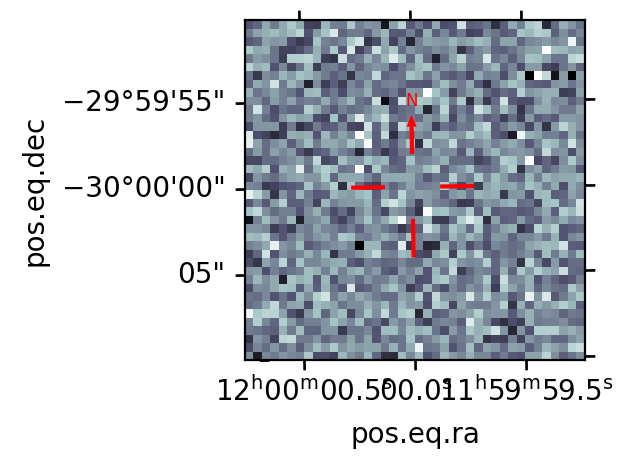

In [ ]:
result = get_single_cutout(
    ra_deg=180.0,
    dec_deg=-30.0,
    time_mjd=58200.0,
    observatory_code="Q55"
)

In [ ]:
result = get_single_cutout(
    ra_deg=180.0,
    dec_deg=-30.0,
    time_mjd=58200.0,
    observatory_code="Q55",
    plot_kwargs={"velocity_vector": False}  # Control plotting here
)

TypeError: get_single_cutout() got an unexpected keyword argument 'plot_kwargs'

In [ ]:
def get_single_cutout(
    ra_deg: float,
    dec_deg: float,
    time_mjd: float,
    delta_time: float = 20.0,
    observatory_code: str = "Q55",
    out_dir: str = "cutouts",
    save_png: bool = True,
    velocity_vector: bool = False,  # Add specific plot control parameters
    dpi: int = 300
) -> dict:
    """Get a single cutout image and save as PNG."""
    # Create request DataFrame
    cutout_request = pd.DataFrame({
        'observatory_code': [observatory_code],
        'exposure_start_mjd': [float(time_mjd)],
        'ra_deg': [float(ra_deg)],
        'dec_deg': [float(dec_deg)],
        'height_arcsec': [20.0],
        'width_arcsec': [20.0],
        'delta_time': [float(delta_time)]
    })

    # Get cutouts
    results, _ = get_cutouts(
        cutout_request,
        out_dir=pathlib.Path(out_dir),
        timeout=180,
        use_cache=True
    )

    if save_png and results and len(results) > 0:
        plot_data = pd.DataFrame({
            'path': [results[0].get('cutout_image_path', results[0]['cutout_url'])],
            'ra': [ra_deg],
            'dec': [dec_deg],
            'vra': [0.0],
            'vdec': [0.0],
            'obj_ra': [ra_deg],
            'obj_dec': [dec_deg],
            'mag': [np.nan],
            'mag_sigma': [np.nan],
            'filter': [results[0]['filter']],
            'obscode': [observatory_code],
            'exposure_start': [results[0]['exposure_start_mjd']],
            'exposure_duration': [results[0]['exposure_duration']]
        })

        # Plot with specific parameters
        fig, ax = plot_cutouts(
            plot_data,
            velocity_vector=velocity_vector,
            dpi=dpi
        )

        png_path = str(results[0]['cutout_url']).replace('.fits', '.png')
        fig.savefig(png_path, bbox_inches="tight")
        plt.close(fig)
        results[0]['png_path'] = png_path

    return results[0] if results and len(results) > 0 else None

ValueError: Format '005555555555555556' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

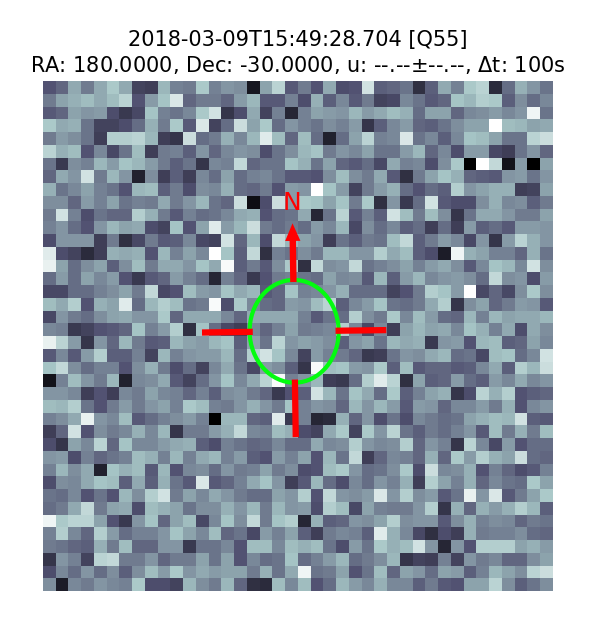

In [ ]:
result = get_single_cutout(
    ra_deg=180.0,
    dec_deg=-30.0,
    time_mjd=58200.0,
    observatory_code="Q55"
)

In [ ]:
def get_single_cutout(
    ra_deg: float,
    dec_deg: float,
    time_mjd: float,
    delta_time: float = 20.0,
    observatory_code: str = "Q55",
    out_dir: str = "cutouts",
    save_png: bool = True,
    velocity_vector: bool = False
) -> dict:
    """Get a single cutout image and save as PNG."""
    # Create output directory if it doesn't exist
    out_path = pathlib.Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Create request DataFrame
    cutout_request = pd.DataFrame({
        'observatory_code': [observatory_code],
        'exposure_start_mjd': [float(time_mjd)],
        'ra_deg': [float(ra_deg)],
        'dec_deg': [float(dec_deg)],
        'height_arcsec': [20.0],
        'width_arcsec': [20.0],
        'delta_time': [float(delta_time)]
    })

    # Get cutouts
    results, _ = get_cutouts(
        cutout_request,
        out_dir=out_path,
        timeout=180,
        use_cache=True
    )

    if save_png and results and len(results) > 0:
        # Create plot data DataFrame
        plot_data = pd.DataFrame({
            'path': [results[0].get('cutout_image_path', results[0]['cutout_url'])],
            'ra': [ra_deg],
            'dec': [dec_deg],
            'vra': [0.0],
            'vdec': [0.0],
            'obj_ra': [ra_deg],
            'obj_dec': [dec_deg],
            'mag': [np.nan],
            'mag_sigma': [np.nan],
            'filter': [results[0]['filter']],
            'obscode': [observatory_code],
            'exposure_start': [results[0]['exposure_start_mjd']],
            'exposure_duration': [results[0]['exposure_duration']]
        })

        # Plot and save as PNG
        fig, ax = plot_cutouts(plot_data)

        # Generate a proper filename using timestamp
        timestamp = Time(results[0]['exposure_start_mjd'], format='mjd').isot
        png_path = out_path / f"cutout_{timestamp}_ra{ra_deg:.4f}_dec{dec_deg:.4f}.png"

        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        plt.close(fig)

        # Add PNG path to results
        results[0]['png_path'] = str(png_path)

    return results[0] if results and len(results) > 0 else None

/usr/local/lib/python3.10/dist-packages/cutouts/plot.py:223: RuntimeWarning: invalid value encountered in scalar divide
  vra_hat = vra / np.sqrt(vra**2 + vdec**2)
/usr/local/lib/python3.10/dist-packages/cutouts/plot.py:224: RuntimeWarning: invalid value encountered in scalar divide
  vdec_hat = vdec / np.sqrt(vra**2 + vdec**2)


AttributeError: 'list' object has no attribute 'T'

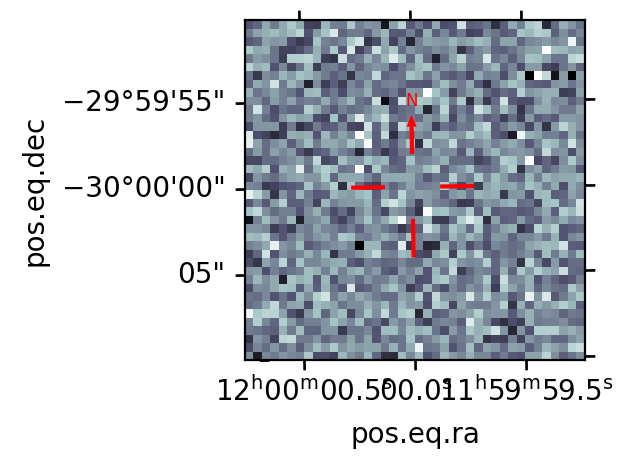

In [ ]:
result = get_single_cutout(
    ra_deg=180.0,
    dec_deg=-30.0,
    time_mjd=58200.0,
    observatory_code="Q55",
    out_dir="cutouts"  # This directory will be created if it doesn't exist
)